# Оглавление
* [Простая линейная регрессия](#Простая-линейная-регрессия)
* [Уравнение регрессии](#Уравнение-регрессии)
* [Подогнанные значения и остатки](#Подогнанные-значения-и-остатки)
* [Наименьшие квадраты](#Наименьшие-квадраты)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)
* [](#)

Нигде единение между статистикой и наукой о данных не является более тесным, чем в контексте предсказаания. Этот процесс тренировки модели на данных, где исход известен, для послоедующего применения к данным, где исход не известен, называется **контролируемым самообучением**. Связь между наукой о данных и статистикой лежит в области *обнаружения аномалий*, где диагностика регресии предназначена для аналоиза данных и улучшения регрессионной модели.

In [18]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage


import matplotlib.pyplot as plt

from dmba import stepwise_selection
from dmba import AIC_score

In [19]:
%matplotlib inline

# Простая линейная регрессия

Простая линейная регрессия, или парная линейная регрессия, моделирует связь между величиной одной переменной и величиной второй. Корреляция - еще один способ измерить то, каким образом две переменные связаны между собой. Корреляция измеряет силу связи между двумя переменными, регрессия оценивает *природу* этой связи количественно.

**Отклик (response)** - (зависимая переменная, Y-переменная, цель, исход) переменная, которую пытаемся предсказать. 

**Независимая переменная (independent variable)** - (X-переменная, предсказатель, предиктор, предсказательная переменная, признак, атрибут) переменная, которая используется для предсказания отклика.

**Запись (record)** - (строка, сдучай, прецедент, образец, экземпляр, пример) вектор, который состоит из значений предсказателей и значения исхода для отдельного элемента данных или случая.

**Пересечение (intercept)** - ($b_0$, $\beta_0$, точка пересечения, коэффициент сдвига на оси y) пересечение регрессионной прямой с осью *y*, т.е. предсказанное значение, когда X=0.

**Коэффициент регрессии (regression coeficient)** - ($b_1$, $\beta_1$, наклон, оценка параметров, веса, угловой коэффициент) наклон регрессионной прямой по отношению к оси *x*.

**Подогнанные значения (fitted values)** - (предсказанные значения) оценки $\bar{Y_i}$, полученные из регрессионной прямой.

**Остатки (residuals)** - (ошибки) разница между наблюдаемыми значениями и подогнанными значенями.

**Наименьшие квадраты (least squares)** - (обычный метод наименьших квадратов, обычный МНК) метод подгонки регрессии путем минимизации суммы квадратов остатков.

# Уравнение регрессии

%matplotlib inline



Простая линейная регрессия оценивает, насколько именно изменится Y, когда Х изменяется на некоторую величину. $$Y = b_0 + b_1X$$
$b_0$ - пересечение (константа)

$b_1$ - наклон по отношению к оси x

Y - цель

X - вектор признаков

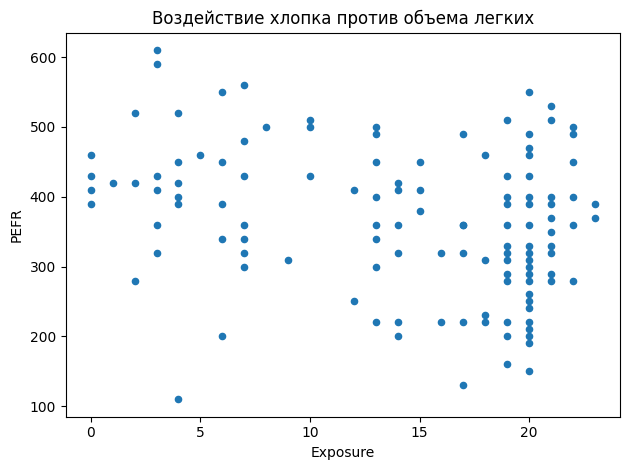

In [26]:
lung = pd.read_csv('data/LungDisease.csv')

lung.plot.scatter(x='Exposure', y='PEFR')

plt.title('Воздействие хлопка против объема легких')
plt.tight_layout()
plt.show()

Простая линейная регрессия пытается отыскать "оптимальную" прямую, чтобы предсказать отклик PEFR, как функцию от предсказательной переменной Exposure. $$PEFR = b_0 + b_1 * Exposure$$

In [28]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


Коэффициент регрессии, или $b_1$, может быть истолкован так: для каждого дополнительного года, в течении которого рабочий подвергается воздействию хлопчатобумажной пыли, результат измерения PEFR у рабочего уменьшается на -4,185.

В Python класс LinearRegression из пакета scikit-learn (пакет statsmodels содержит имплементацию линейной регрессии).

Регрессионная пряма указанной модели изображена ниже.

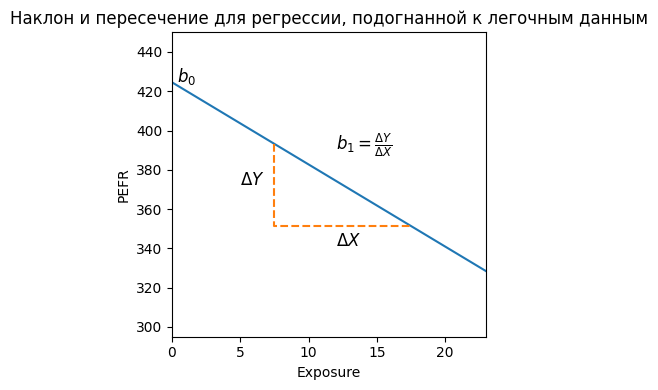

In [29]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel('Exposure')
ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')

x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')

plt.title("Наклон и пересечение для регрессии, подогнанной к легочным данным")
plt.tight_layout()
plt.show()

# Подогнанные значения и остатки

В общем случае данные не ложатся ровно на прямую, поэтому уравнение регрессии должно включать явный остаточный член $e_i$.
$$Y = b_0 + b_1X + e_i$$

Подогнанные значения (предсказанные значения) обозначаются как $\hat{Y_i}$ (Y-hat, Yс шляпой). $$\hat{Y_i} = \hat{b_0} + \hat{b_1}X_i$$

$\hat{b_0}$ и $\hat{b_1} говорит, о том что эти коэффициенты оцениваются по отношению к известным, т.е. являются оценочными.

> Символ $\hat{b}$ (b с шляпой) является оценкой неизвестного параметра b. Оценка имеет неопределенность, тогда как истинное значение фиксировано. В байесовой статистике истинное значение считается случайной величиной с заданным распределением. В байесовом контексте вместо оценок неизвестных параметров существует априорные и апостериорные распределения.

Остатки $\hat{e_i}$ вычисляем путем вычитания предсказанных значений из исходных данных: $\hat{e_i} = Y_i - \hat{Y_i}$

На основе класса LinearRegression пакета scikit-learn используем метод *predict* на тренировачных данных, чтобы получить подогнанные значения *fitted*, и в последующем получить остатки *residuals*.

In [30]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

Остатки - это длина вертикальных пунктирных линий от данных до прямой.

Остатки от регрессионной прямой (для того чтобы разместитьт все данные, шкала оси у отличается от предыдущего графика, отсюда и очивидным образом другой угол наклона)

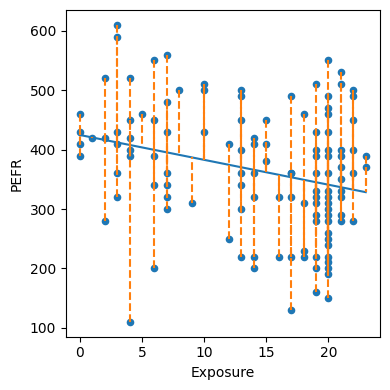

In [31]:
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted): 
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

# Наименьшие квадраты